In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
print("hello world")

hello world


In [9]:
pd.set_option('display.max_rows', None)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [10]:
file_path = 'C:/python_course/final_project/eunbi'

# 거래량 변화율

In [11]:
trans_df = pd.read_csv(file_path+'/transactions_total.csv', encoding = 'cp949')
trans_df.head()

,시군구,법정동,유형,용도지역,전용/연면적(㎡),건축물주용도,거래금액(만원),층,계약연월
0,경기도 성남시 분당구,구미동,집합,근린상업,30.31,제2종근린생활,69500,1.0,2023-01
1,경기도 성남시 분당구,금곡동,집합,중심상업,45.24,제2종근린생활,69000,1.0,2023-01
2,경기도 성남시 분당구,서현동,집합,근린상업,19.94,교육연구,9753,2.0,2023-01
3,경기도 성남시 분당구,서현동,집합,근린상업,75.66,제1종근린생활,37000,NaN,2023-01
4,경기도 성남시 분당구,서현동,집합,근린상업,75.66,제1종근린생활,37000,2.0,2023-01


In [12]:
pd.crosstab(trans_df['계약연월'], trans_df['시군구'])

시군구,경기도 성남시 분당구,경기도 성남시 수정구,경기도 성남시 중원구
계약연월,,,
2023-01,23,4,5
2023-02,45,7,11
2023-03,95,18,10
2023-04,65,13,8
2023-05,73,12,13
2023-06,70,14,18
2023-07,52,15,12
2023-08,75,9,6
2023-09,49,10,9


In [13]:
result = trans_df.groupby('계약연월')[['시군구', '법정동']].value_counts(normalize=True) * 100
result

계약연월     시군구          법정동 
2023-01  경기도 성남시 분당구  정자동     25.000000
                      서현동     21.875000
         경기도 성남시 수정구  태평동      9.375000
         경기도 성남시 중원구  금광동      9.375000
         경기도 성남시 분당구  야탑동      9.375000
                      이매동      6.250000
                      구미동      3.125000
         경기도 성남시 중원구  성남동      3.125000
                      상대원동     3.125000
         경기도 성남시 수정구  창곡동      3.125000
         경기도 성남시 분당구  수내동      3.125000
                      금곡동      3.125000
2023-02  경기도 성남시 분당구  구미동     28.571429
                      삼평동     11.111111
         경기도 성남시 수정구  창곡동      9.523810
         경기도 성남시 분당구  서현동      9.523810
                      야탑동      7.936508
         경기도 성남시 중원구  하대원동     4.761905
                      성남동      4.761905
         경기도 성남시 분당구  정자동      4.761905
         경기도 성남시 중원구  도촌동      3.174603
         경기도 성남시 분당구  운중동      3.174603
                      금곡동      3.174603
         경기도 성남시 중원구  여수동      1.587302
             

In [14]:
result.groupby('계약연월').nlargest(3)

계약연월     계약연월     시군구          법정동 
2023-01  2023-01  경기도 성남시 분당구  정자동     25.000000
                               서현동     21.875000
                  경기도 성남시 수정구  태평동      9.375000
2023-02  2023-02  경기도 성남시 분당구  구미동     28.571429
                               삼평동     11.111111
                  경기도 성남시 수정구  창곡동      9.523810
2023-03  2023-03  경기도 성남시 분당구  서현동     43.902439
                               구미동     13.821138
                  경기도 성남시 수정구  창곡동      7.317073
2023-04  2023-04  경기도 성남시 분당구  서현동     19.767442
                               수내동     17.441860
                               정자동     13.953488
2023-05  2023-05  경기도 성남시 분당구  삼평동     16.326531
                               정자동     16.326531
                               구미동     12.244898
2023-06  2023-06  경기도 성남시 분당구  정자동     20.588235
                               구미동     14.705882
                               수내동      8.823529
2023-07  2023-07  경기도 성남시 분당구  구미동     16.455696
                               정자

In [15]:
trans_df2 = trans_df.copy()
trans_df2['계약연월'] = pd.to_datetime(trans_df2['계약연월'])
trans_df2['계약연도'] = trans_df2['계약연월'].dt.year
result = trans_df2.groupby('계약연도')[['시군구', '법정동']].value_counts(normalize=True) * 100
result.groupby('계약연도').nlargest(3)

계약연도  계약연도  시군구          법정동
2023  2023  경기도 성남시 분당구  서현동    14.721346
                         구미동    11.461619
                         정자동    10.515247
2024  2024  경기도 성남시 분당구  야탑동    14.038286
                         정자동    11.212397
                         구미동     9.662716
2025  2025  경기도 성남시 분당구  서현동    11.660079
                         정자동     9.683794
            경기도 성남시 수정구  창곡동     9.189723
Name: proportion, dtype: float64

| 동   | 젠트리피케이션 정도 | 성격          |
| --- | ---------- | ----------- |
| 정자동 | ★★★★☆      | 명확한 젠트리피케이션, 분당 1기 신도시 핵심 상권, 오래된 상권, 높은 유동 인구|
| 서현동 | ★★★☆☆      | 완만한 젠트리피케이션, 카페거리로 유명, 초기: 개성 있는 개인 카페, 현재: 브랜드/프랜차이즈 다수 |
| 야탑동 | ★★☆☆☆      | 부분적 상권 재편   |
| 구미동 | ★☆☆☆☆      | 거의 없음       |
| 창곡동 | ☆☆☆☆☆      | 위례신도시 (해당 없음) |


[Text(0, 0, '2023-01'),
 Text(1, 0, '2023-02'),
 Text(2, 0, '2023-03'),
 Text(3, 0, '2023-04'),
 Text(4, 0, '2023-05'),
 Text(5, 0, '2023-06'),
 Text(6, 0, '2023-07'),
 Text(7, 0, '2023-08'),
 Text(8, 0, '2023-09'),
 Text(9, 0, '2023-10'),
 Text(10, 0, '2023-11'),
 Text(11, 0, '2023-12'),
 Text(12, 0, '2024-01'),
 Text(13, 0, '2024-02'),
 Text(14, 0, '2024-03'),
 Text(15, 0, '2024-04'),
 Text(16, 0, '2024-05'),
 Text(17, 0, '2024-06'),
 Text(18, 0, '2024-07'),
 Text(19, 0, '2024-08'),
 Text(20, 0, '2024-09'),
 Text(21, 0, '2024-10'),
 Text(22, 0, '2024-11'),
 Text(23, 0, '2024-12'),
 Text(24, 0, '2025-01'),
 Text(25, 0, '2025-02'),
 Text(26, 0, '2025-03'),
 Text(27, 0, '2025-04'),
 Text(28, 0, '2025-05'),
 Text(29, 0, '2025-06'),
 Text(30, 0, '2025-07'),
 Text(31, 0, '2025-08'),
 Text(32, 0, '2025-09'),
 Text(33, 0, '2025-10'),
 Text(34, 0, '2025-11'),
 Text(35, 0, '2025-12')]

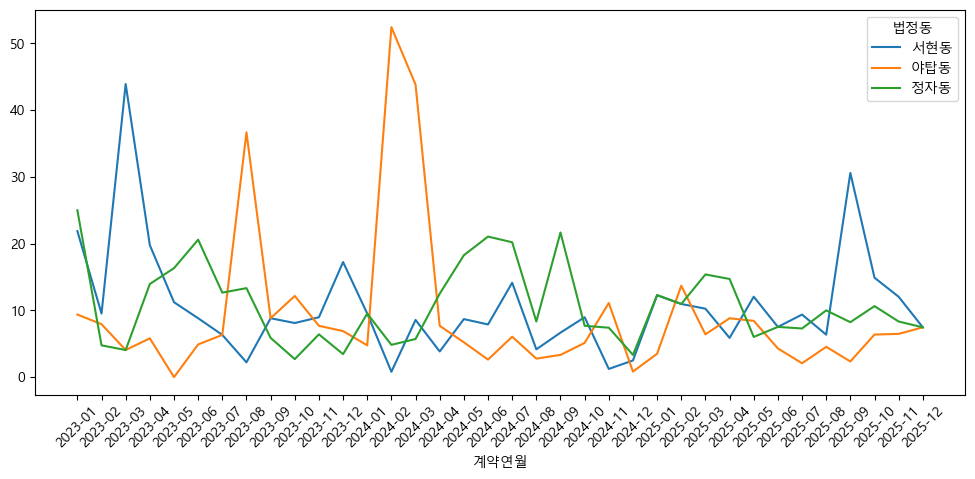

In [16]:
pivot_df = (
    trans_df
    .groupby(['계약연월', '법정동'])
    .size()
    .unstack(fill_value=0)
)

ratio = pivot_df.div(pivot_df.sum(axis=1), axis=0) *100

ax = ratio[['서현동', '야탑동', '정자동']].plot(figsize=(12, 5))
ax.set_xticks(range(len(ratio.index)))
ax.set_xticklabels(ratio.index, rotation=45)

<Axes: xlabel='건축물주용도'>

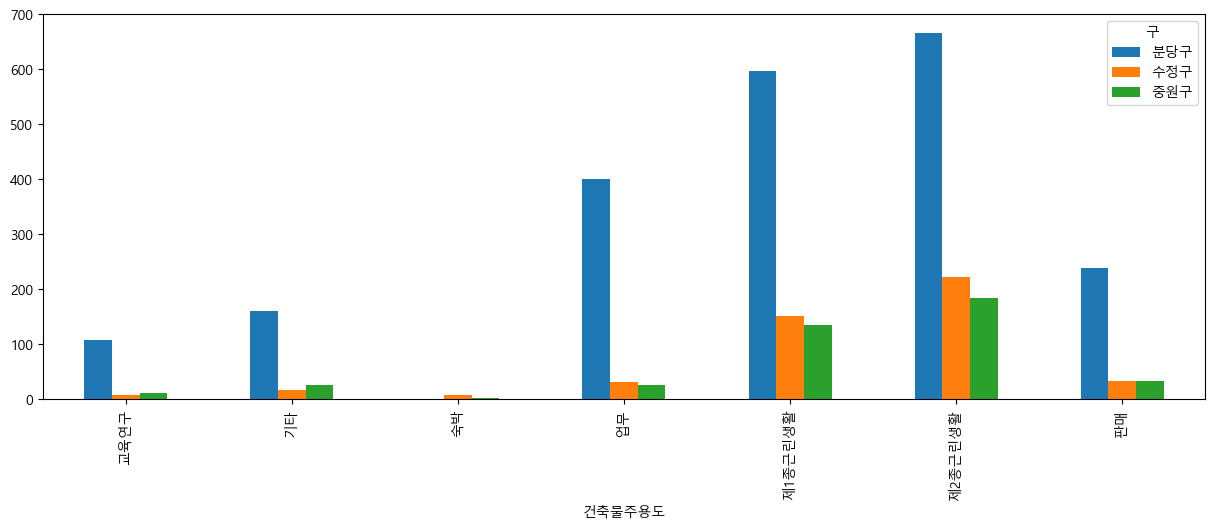

In [17]:
pivot = (
    trans_df[trans_df['시군구'].str.contains('분당구|수정구|중원구', na=False)]
    .assign(구=lambda x: x['시군구'].str.extract('(분당구|수정구|중원구)'))
    .groupby(['구', '건축물주용도'])
    .size()
    .unstack(fill_value=0)
)

pivot.T.plot(kind='bar', figsize=(15,5))

<Axes: xlabel='용도지역'>

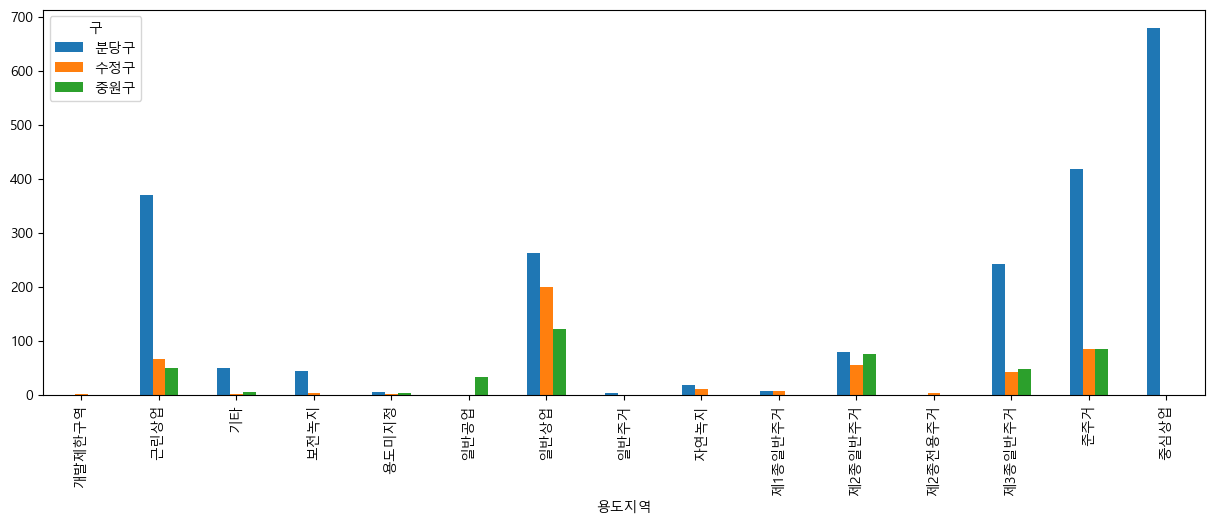

In [18]:
pivot = (
    trans_df[trans_df['시군구'].str.contains('분당구|수정구|중원구', na=False)]
    .assign(구=lambda x: x['시군구'].str.extract('(분당구|수정구|중원구)'))
    .groupby(['구', '용도지역'])
    .size()
    .unstack(fill_value=0)
)

pivot.T.plot(kind='bar', figsize=(15,5))

# 신규기업 증가율

In [ ]:
corp_df = pd.read_csv(file_path+'/new_corp_total.csv', encoding = 'utf-8')
corp_df.head()


,date,sido_nm,sigun_nm,admi_nm,dong_code,induty_pri_cd,induty_pri_nm,induty_med_cd,induty_med_nm,ncr_crp_comp_cn
0,2023-01,경기,성남시 분당구,구미1동,4113566500,10G0000000,G 도매 및 소매업(45~47),10G4600000,도매 및 상품 중개업,3
1,2023-01,경기,성남시 분당구,구미1동,4113566500,10J0000000,J 정보통신업(58~63),10J5800000,출판업,1
2,2023-01,경기,성남시 분당구,구미1동,4113566500,10J0000000,J 정보통신업(58~63),10J6200000,"컴퓨터 프로그래밍, 시스템 통합 및 관리업",1
3,2023-01,경기,성남시 분당구,구미1동,4113566500,10L0000000,L 부동산업(68),10L6800000,부동산업,1
4,2023-01,경기,성남시 분당구,구미1동,4113566500,10N0000000,"N 사업시설 관리, 사업 지원 및 임대 서비스업(74~76)",10N7400000,사업시설 관리 및 조경 서비스업,1


<Axes: xlabel='date'>

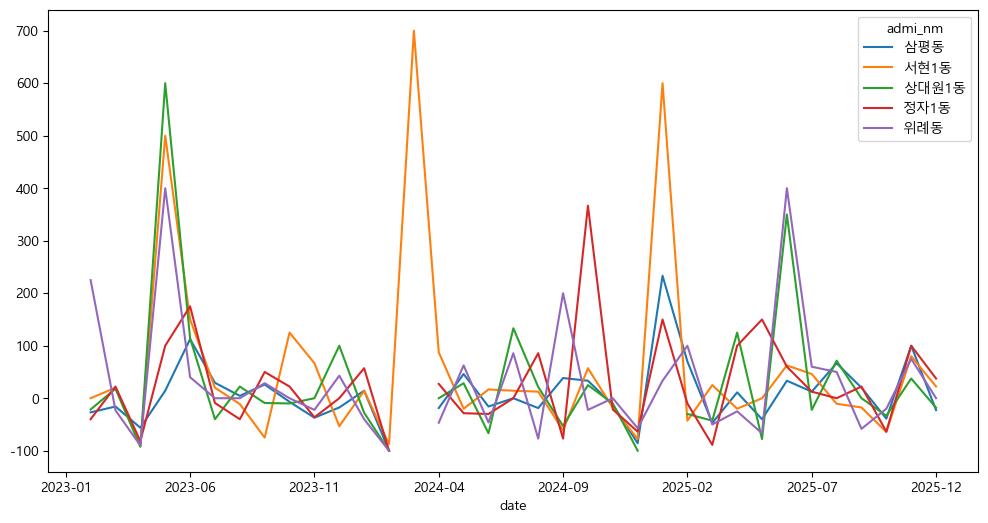

In [ ]:
pivot_df = (
    corp_df
    .pivot_table(
        index='date',
        columns='admi_nm',
        values='ncr_crp_comp_cn',
        aggfunc='sum',
        fill_value=0
    )
    .sort_index()
)

growth_rate = pivot_df.pct_change() * 100

top_dongs = pivot_df.sum().nlargest(5).index
growth_rate[top_dongs].plot(figsize=(12,6))


# 매출액 변화율

In [ ]:
sales_df = pd.read_csv(file_path+'/전처리완료_카드(매출).csv', encoding ='utf-8')
sales_df.head()

,ta_ymd,cty_rgn_no,admi_cty_no,card_tpbuz_cd,card_tpbuz_nm_1,card_tpbuz_nm_2,hour,sex,age,day,amt,cnt
0,2023-01-01,41131,41131510,D01,소매/유통,가전제품,4,M,5,7,9251291,2
1,2023-01-01,41131,41131510,D01,소매/유통,가전제품,5,F,5,7,62392,4
2,2023-01-01,41131,41131510,D01,소매/유통,가전제품,5,F,6,7,153920,2
3,2023-01-01,41131,41131510,D01,소매/유통,가전제품,5,F,7,7,21515,2
4,2023-01-01,41131,41131510,D01,소매/유통,가전제품,5,M,6,7,544320,4


In [ ]:
sales_df2 = sales_df.copy()

sales_df2['ta_ym'] = pd.to_datetime(
    sales_df2['ta_ymd'],
    format='%Y%m%d'
)

MemoryError: Unable to allocate 4.55 GiB for an array with shape (7, 87263128) and data type int64

In [ ]:
sales_df2['ta_ym'] = sales_df2['ta_ymd'].dt.to_period('M')

AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:

pivot_df = (
    corp_df
    .pivot_table(
        index='date',
        columns='admi_nm',
        values='ncr_crp_comp_cn',
        aggfunc='sum',
        fill_value=0
    )
    .sort_index()
)

growth_rate = pivot_df.pct_change() * 100

top_dongs = pivot_df.sum().nlargest(5).index
growth_rate[top_dongs].plot(figsize=(12,6))